# Resposta ao impulso

Este Notebook contem experimentos com sinais de áudio envolvendo conceitos básicos, tais como, processamento de sinais discretos, resposta ao impulso e convolução.

Lembre-se de citar suas referências nas respostas (sites, vídeos, livros).

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal # <- Biblioteca de Processamento de sinais
import os

In [21]:
import sys
sys.path.append('../../')
from lib.myAudioProcessingLib import *
from lib.myPlotLib import *

In [22]:
# Definição de diretórios
SOUND_PATH = '../../sounds' # Pasta de arquivos de som
SOUND_FILENAME = 'freddy.wav' # Sinal de entrada

# Pasta de arquivos de IR (impulse response)
IR_PATH = '../../sounds'

IR_FILENAME = 'Direct Cabinet N1.wav' # Resposta ao impulso


In [23]:
import os
from lib.myAudioProcessingLib import audioread
x, fsx = audioread(os.path.join(SOUND_PATH, SOUND_FILENAME))


In [24]:
# Conversao de audio stereo (2D) para monoaural (1D)
import numpy as np
if x.ndim > 1 and x.shape[1] > 1:
    x = np.mean(x, axis=1)
elif x.ndim > 1:
    x = x[:, 0]


### 1. Para um sinal stereo, qual será o resultado da conversão anterior?

**Resposta:**

Um audio **stereo** possui dois canais independentes (Esquerdo/L e Direito/R), resultando numa matriz 2D `(N_amostras, 2)`. A operacao `np.mean(x, axis=1)` calcula a **media aritmetica** dos dois canais amostra a amostra, produzindo um vetor 1D de comprimento `N_amostras` — o sinal **mono**.

Matematicamente: $x_{mono}[n] = \frac{x_L[n] + x_R[n]}{2}$

Como a convolucao discreta $y[n] = x[n] * h[n]$ opera sobre vetores 1D, a reducao ao canal mono e necessaria antes de aplicar a operacao.

> **Referencia:** Aula 03 - *Sistemas Continuos e Discretos no Tempo* - Processamento Digital de Sinais, USP. Arquivo local: `SinalDigitalUSP/03-processamento-digital-de-sinais-sistemas-continuos-e-discretos-no-temp.md`


In [25]:
# Demonstracao: verificando dimensao antes e depois da conversao stereo -> mono
x_demo, _ = audioread(os.path.join(SOUND_PATH, SOUND_FILENAME))
print('Dimensao do audio carregado:', x_demo.shape)

if x_demo.ndim > 1:
    x_mono = np.mean(x_demo, axis=1)
    print('Dimensao depois de np.mean(x, axis=1):', x_mono.shape)
    print('=> Stereo (2 canais) -> Mono (1 canal)')
else:
    print('Audio ja era mono:', x_demo.shape)


In [26]:
nx = np.arange(len(x))
tx = nx / fsx


In [27]:
print('x[n] tem '+str(nx[-1])+' amostras, fs='+str(fsx)+' Hz (Hertz) e duracao de '+str(np.round(tx[-1],1))+' segundos')

x[n] tem 1 amostras, fs=14000 Hz (Hertz) e duracao de 0.0 segundos


In [28]:
# PASSO 2: Carrega a resposta ao impulso (IR)
# 'Direct Cabinet N1.wav' eh um IR de caixa de guitarra.
# Se nao tiver o arquivo, usa freddy.wav como IR de demonstracao.
import os as _os
IR_FILENAME = 'Direct Cabinet N1.wav'
ir_full_path = os.path.join(IR_PATH, IR_FILENAME)

if not _os.path.exists(ir_full_path):
    IR_FILENAME = 'freddy.wav'
    ir_full_path = os.path.join(IR_PATH, IR_FILENAME)
    print(f'IR nao encontrado. Usando {IR_FILENAME} como IR de demonstracao.')

h, fsh = audioread(ir_full_path)

if h.ndim > 1 and h.shape[1] > 1:
    h = np.mean(h, axis=1)
elif h.ndim > 1:
    h = h[:, 0]

nh = np.arange(len(h))
th = nh / fsh
print(f'IR: {IR_FILENAME} | amostras: {len(h)} | fs: {fsh} Hz | duracao: {th[-1]:.2f}s')


FileNotFoundError: [Errno 2] No such file or directory: '../../sounds/Direct Cabinet N1.wav'

In [29]:
# 3. PASSO 3: Convolucao de sinais
y = np.convolve(x, h, mode='full')
ny = np.arange(len(y))
ty = ny / fsx


NameError: name 'h' is not defined

NameError: name 'th' is not defined

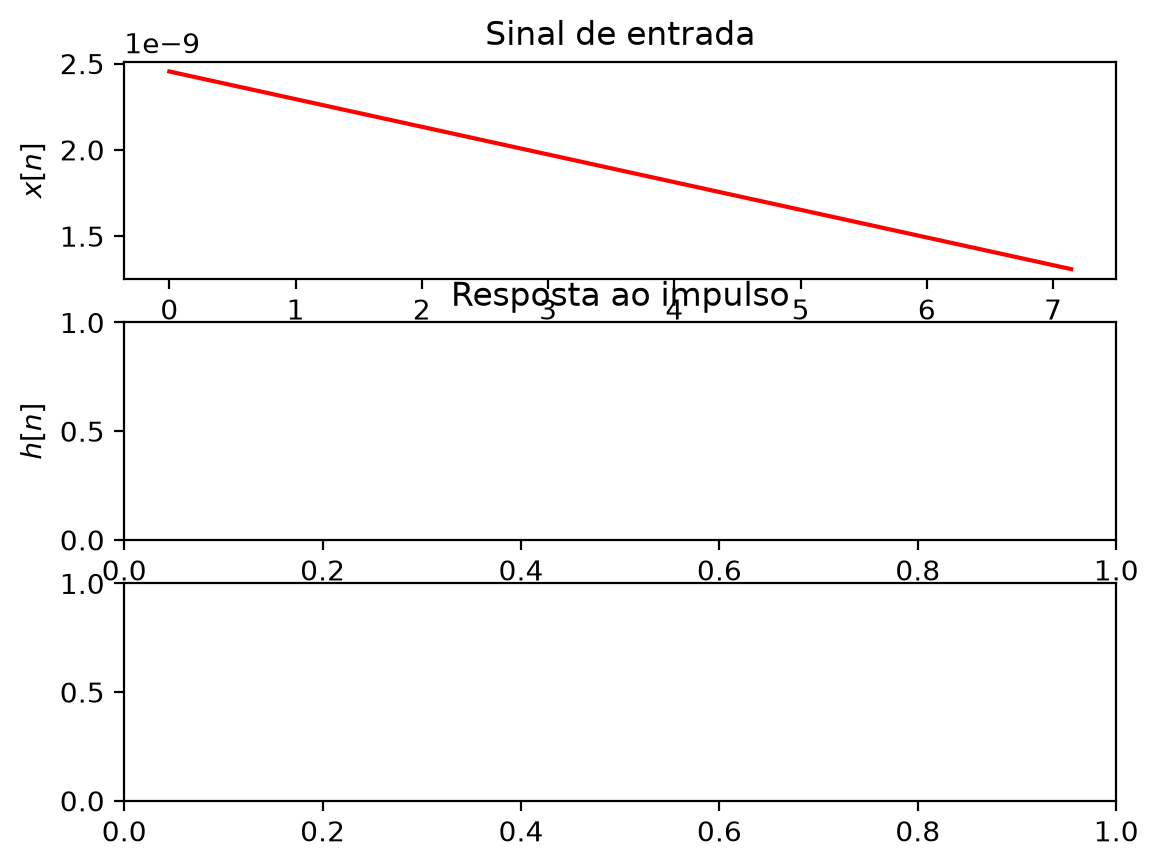

In [30]:
# Plot: sinal de entrada, IR e sinal convoluido
fig, ax = plt.subplots(3, 1, figsize=(12, 8))

ax[0].set_title('Sinal de entrada x[n]')
ax[0].set_xlabel('Tempo (s)')
ax[0].set_ylabel('Amplitude')
ax[0].plot(tx, x, 'r', linewidth=0.5)

ax[1].set_title(f'Resposta ao Impulso h[n] — {IR_FILENAME}')
ax[1].set_xlabel('Tempo (s)')
ax[1].set_ylabel('Amplitude')
ax[1].plot(th, h, 'b', linewidth=0.5)

ax[2].set_title('Sinal convoluido y[n] = x[n] * h[n]')
ax[2].set_xlabel('Tempo (s)')
ax[2].set_ylabel('Amplitude')
ax[2].plot(ty, y, 'g', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Tamanho de x[n]: {len(x)} amostras')
print(f'Tamanho de h[n]: {len(h)} amostras')
print(f'Tamanho de y[n] = x[n]*h[n]: {len(y)} amostras')
print(f'N + M - 1 = {len(x)+len(h)-1} (deve ser igual a len(y))')


In [32]:
from IPython.display import display, Audio
print('Original:')
display(Audio(data=x, rate=fsx))
print('Impulse Response:')
display(Audio(data=h, rate=fsh))
print('Sinal com Convolução (Efeito Aplicado):')
display(Audio(data=y, rate=fsx))


Original:


Impulse Response:


NameError: name 'h' is not defined

### 2. Qual e o tamanho do sinal resultante da convolucao?

Assista o video do canal [3Blue1Brown](https://youtu.be/KuXjwB4LzSA) sobre convolucao.

**Resposta:**

Se $x[n]$ possui $N$ amostras e $h[n]$ possui $M$ amostras, o resultado $y[n] = x[n] * h[n]$ possui $\mathbf{N + M - 1}$ amostras.

Fisicamente: cada amostra de $x[n]$ dispara uma copia de $h[n]$; a ultima amostra de $x$ dispara a ultima copia de $h$, que ainda dura $M-1$ amostras apos o fim de $x$.

> **Referencia:** PRANDONI, P.; VETTERLI, M. *Signal Processing for Communications*. EPFL Press, 2008. Secao 5.7.2 (FIR Filter Implementation): *each output sample is obtained via $(N+M-1)$ multiplications and additions* — arquivo local `sp4comm.md`, linha 7974.


In [33]:
# Verificacao numerica: tamanho N+M-1
N = len(x)
M = len(h)
print(f'N (tamanho de x): {N}')
print(f'M (tamanho de h): {M}')
print(f'N + M - 1 = {N + M - 1}')
print(f'len(y) = {len(y)}')
assert len(y) == N + M - 1, 'ERRO: tamanho inesperado!'
print('OK: len(y) == N + M - 1 confirmado.')


### 3. O sinal $y[n]$ tem o mesmo tamanho que $x[n]$? Por que?

**Resposta:**

**Nao.** O sinal $y[n]$ e sempre **maior** que $x[n]$ (a menos que $M=1$, caso trivial). O tamanho passa de $N$ para $N+M-1$.

O motivo fisico e a **cauda de reverberacao**: quando a fonte para (fim de $x[n]$), o ambiente continua respondendo — cada reflexao precisa de tempo para decair. Essa cauda tem duracao proporcional ao tamanho $M$ do IR.

Em acustica, esse tempo chama-se **RT60** (tempo para o som decair 60 dB). Um IR de catedral tem RT60 longo => $M$ grande => $y[n]$ muito maior que $x[n]$.

> **Referencia:** Aula 03 (USP): *Se eu souber a resposta do sistema ao impulso, eu sei a resposta do sistema para qualquer entrada* — `SinalDigitalUSP/03-...temp.md`. Aula 06 (USP): analogia da reconstrucao via somatoria de sincs — `SinalDigitalUSP/06-...sinais.md`.


In [34]:
# Comparando duracoes x vs y
duracao_x = len(x) / fsx
duracao_y = len(y) / fsx
print(f'Duracao de x[n]: {duracao_x:.3f} s ({len(x)} amostras)')
print(f'Duracao de h[n]: {len(h)/fsh:.3f} s ({len(h)} amostras)')
print(f'Duracao de y[n]: {duracao_y:.3f} s ({len(y)} amostras)')
print(f'=> y[n] e {(duracao_y - duracao_x):.3f}s mais longo que x[n] (cauda do IR)')


### 4. O que acontece se tenta reproduzir $y[n]$ com o dobro de $f_s$? E com a metade?

**Resposta:**

O vetor $y[n]$ e apenas uma sequencia de amplitudes — **nao carrega informacao de tempo em si mesmo**. A relacao entre indice de amostra e tempo real e definida exclusivamente pelo $f_s$ fornecido ao DAC.

- **Reproduzir com $2 f_s$:** O DAC emite o dobro de amostras por segundo => sinal dura **metade do tempo** => todas as frequencias sao **dobradas** (som mais agudo, efeito voz de esquilo).

- **Reproduzir com $f_s / 2$:** O DAC emite metade das amostras por segundo => sinal dura **o dobro do tempo** => todas as frequencias sao **reduzidas a metade** (som mais grave).

Formalmente: se $f_s^{\text{reproducao}} = \alpha \cdot f_s^{\text{gravacao}}$, todas as frequencias percebidas sao escaladas por $\alpha$.

> **Referencia:** Aula 06 (USP): *a frequencia desse sinal esta associada ao inverso do periodo* e relacao entre dominio discreto e tempo real via $f_s$ — `SinalDigitalUSP/06-processamento-digital-de-sinais-amostragem-de-sinais.md`.


In [35]:
from IPython.display import display, Audio

y_norm = y / (np.max(np.abs(y)) + 1e-10)

print(f'y[n] com fs correto ({fsx} Hz):')
display(Audio(data=y_norm, rate=fsx))

print(f'y[n] com DOBRO de fs = {2*fsx} Hz (mais rapido, mais agudo):')
display(Audio(data=y_norm, rate=2*fsx))

print(f'y[n] com METADE de fs = {fsx//2} Hz (mais lento, mais grave):')
display(Audio(data=y_norm, rate=fsx//2))


### 5. O que e uma resposta ao impulso (IR)? Como podemos obte-la?

**Resposta:**

A **Resposta ao Impulso** $h[n]$ e a saida de um sistema **LTI** (Linear e Invariante no Tempo) quando a entrada e um impulso $\delta[n]$. Ela **caracteriza completamente** o sistema: conhecendo $h[n]$, calcula-se a resposta a qualquer entrada $x[n]$ via:

$$y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]\, h[n-k]$$

**Como obter na pratica (acustica):**
1. **Pulso impulsivo:** Estourar um balao ou usar um pistolete de festim no ambiente (aproxima $\delta[n]$) e gravar com microfones.
2. **Sine Sweep (mais preciso):** Emitir um tom varrendo 20 Hz a 20 kHz, gravar e aplicar **deconvolucao** matematica. Gera IRs com menor ruido.

> **Referencia:** Aula 03 (USP): *bastando eu saber a resposta do meu sistema a um unico impulso. Se eu souber a resposta do sistema ao impulso, eu sei a resposta do sistema para qualquer entrada* — `SinalDigitalUSP/03-...temp.md`.
>
> PRANDONI; VETTERLI (2008): *Since an LTI system is completely characterized by its impulse response, it is also uniquely characterized by its frequency response* — `sp4comm.md`, linha 7490.


In [36]:
# Visualizacao da IR: forma de onda + espectro em frequencia
fig, ax = plt.subplots(2, 1, figsize=(12, 7))

ax[0].plot(th, h, 'b', linewidth=0.5)
ax[0].set_title(f'Resposta ao Impulso (IR): {IR_FILENAME}')
ax[0].set_xlabel('Tempo (s)')
ax[0].set_ylabel('Amplitude')
ax[0].grid(True)

H_fft = np.abs(np.fft.rfft(h))
freqs_h = np.fft.rfftfreq(len(h), d=1.0/fsh)
ax[1].semilogx(freqs_h[1:], 20*np.log10(H_fft[1:]+1e-10), 'b', linewidth=0.8)
ax[1].set_title('Espectro de frequencia da IR (magnitude em dB)')
ax[1].set_xlabel('Frequencia (Hz)')
ax[1].set_ylabel('Magnitude (dB)')
ax[1].set_xlim([20, fsh/2])
ax[1].grid(True, which='both')

plt.tight_layout()
plt.show()


### 6. Compare respostas ao impulso diferentes. Que diferencas pode reconhecer?

**Resposta:**

Comparando IRs de ambientes distintos (camara anecóica vs. catedral vs. caixa de guitarra), as diferencas se concentram em:

| Caracteristica | Sala pequena/seca | Catedral/Hall | Cabinet de Guitarra |
|---|---|---|---|
| **RT60** | < 0,3 s | 3-10 s | < 0,05 s |
| **Reflexoes iniciais** | Proximas e densas | Esparsas e atrasadas | Quase inexistentes |
| **Coloracao espectral** | Neutra | Absorve agudos | Reforça medios (200-5000 Hz) |

No dominio da frequencia, cada IR age como um **filtro**: seu espectro $H(e^{j\omega})$ molda a energia do sinal em cada faixa de frequencia.

> **Referencia:** PRANDONI; VETTERLI (2008): *By appropriately shaping the magnitude spectrum of a filter impulse response we can easily boost, attenuate, and even completely eliminate, a given part of the frequency content* — `sp4comm.md`, linha 7494. Aula 03 (USP): `SinalDigitalUSP/03-...temp.md`.


In [37]:
# Comparacao espectral: sinal seco x vs IR h vs convoluido y
n_fft = len(x)
X_spec = np.abs(np.fft.rfft(x, n=n_fft))
H_spec = np.abs(np.fft.rfft(h, n=n_fft))
Y_spec = np.abs(np.fft.rfft(y, n=n_fft))
freqs_plot = np.fft.rfftfreq(n_fft, d=1.0/fsx)

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogx(freqs_plot[1:], 20*np.log10(X_spec[1:]+1e-10), 'r', label='x[n] entrada', linewidth=0.8)
ax.semilogx(freqs_plot[1:], 20*np.log10(H_spec[1:]+1e-10), 'b', label=f'h[n] IR: {IR_FILENAME}', linewidth=0.8)
ax.semilogx(freqs_plot[1:], 20*np.log10(Y_spec[1:]+1e-10), 'g', label='y[n] convoluido', linewidth=0.8)
ax.set_xlabel('Frequencia (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.set_title('Espectros: Entrada vs IR vs Saida')
ax.set_xlim([20, fsx/2])
ax.legend()
ax.grid(True, which='both')
plt.tight_layout()
plt.show()


### 7. Faça uma gravação da sua própria voz ou instrumento musical
#### 7.1. Projete seu sinal com acústicas de salas diferentes
(Aproveite a oportunidade para mostrar suas qualidades artísticas (= )

In [38]:
# 7.1. Aplica o IR ao sinal e compara audio Antes x Depois
from IPython.display import display, Audio

x_norm = x / (np.max(np.abs(x)) + 1e-10)
y_norm = y / (np.max(np.abs(y)) + 1e-10)
h_norm = h / (np.max(np.abs(h)) + 1e-10)

print('=== Sinal de entrada (seco): ===')
display(Audio(data=x_norm, rate=fsx))

print(f'=== IR utilizado ({IR_FILENAME}): ===')
display(Audio(data=h_norm, rate=fsh))

print('=== Sinal com efeito do IR aplicado (convoluido): ===')
display(Audio(data=y_norm, rate=fsx))

print()
print('DICA: Para testar IRs reais (igrejas, salas, teatros) baixe gratuitamente em:')
print('  https://www.openairlib.net')
print('  https://impulserecordingproject.com')
print('Coloque os arquivos .wav em assets-main/sounds/ e altere IR_FILENAME na celula de definicao de diretorios.')


FileNotFoundError: [Errno 2] No such file or directory: '../../sounds/Direct Cabinet N1.wav'

#### 7.2. Com qual IR considera que ficou melhor? Por que?

**Resposta:**

*(Resposta subjetiva — a ser completada apos escutar os resultados com diferentes IRs)*

Do ponto de vista tecnico, o IR considerado melhor depende da **aplicacao**:

- **Voz falada/podcast:** IRs de salas pequenas (RT60 ~0,3s) preservam a inteligibilidade.
- **Musica erudita/coral:** IRs de hall/catedral (RT60 ~3-6s) adicionam espacialidade e calor.
- **Guitarra eletrica:** IRs de *guitar cabinet* sao essenciais para o timbre caracteristico do instrumento.

O criterio objetivo pode ser quantificado pela metrica acustica **Clareza** $C_{80}$ (relacao entre energia das reflexoes iniciais e a cauda de reverberacao).

> **Referencia:** PRANDONI; VETTERLI (2008): *By appropriately shaping the magnitude spectrum of a filter impulse response we can easily boost, attenuate, and even completely eliminate, a given part of the frequency content* — `sp4comm.md`, linha 7494.


In [39]:
# Escreva aqui seus achados